In [ ]:
import math
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cuda')

In [ ]:
HF_DATASET_ID = "zalando-datasets/fashion_mnist"
BATCH_SIZE = 128
LATENT_DIM = 2
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
NUM_WORKERS = 0

CACHE_DIR = Path(".cache")
HF_CACHE_DIR = CACHE_DIR / "huggingface"
OUTPUT_DIR = Path("generated") / "task_2_cvae"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["HF_DATASETS_CACHE"] = str(HF_CACHE_DIR / "datasets")


In [ ]:
dataset = load_dataset(HF_DATASET_ID)


def preprocess_image(image):
    image = image.convert("L")
    x = np.asarray(image, dtype=np.float32) / 255.0
    x = (x >= 0.5).astype(np.float32)
    return torch.from_numpy(x).unsqueeze(0)


class FashionMNISTDataset(Dataset):
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, index):
        sample = self.hf_dataset[index]
        return preprocess_image(sample["image"])


train_dataset = FashionMNISTDataset(dataset["train"])
test_dataset = FashionMNISTDataset(dataset["test"])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
next(iter(train_loader)).shape


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train batches: 469
Test batches: 79


torch.Size([128, 1, 28, 28])

## Part 1: CVAE

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mean = nn.Linear(7 * 7 * 64, latent_dim)
        self.fc_logvar = nn.Linear(7 * 7 * 64, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 7 * 7 * 32)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mean(h), self.fc_logvar(h)

    def reparameterize(self, mean, logvar):
        eps = torch.randn_like(mean)
        return mean + eps * torch.exp(0.5 * logvar)

    def decode(self, z, apply_sigmoid=False):
        h = self.decoder_input(z)
        h = h.view(-1, 32, 7, 7)
        logits = self.decoder(h)
        return torch.sigmoid(logits) if apply_sigmoid else logits

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        logits = self.decode(z)
        return logits, mean, logvar, z


model = CVAE(LATENT_DIM).to(DEVICE)
model


CVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mean): Linear(in_features=3136, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=2, bias=True)
  (decoder_input): Linear(in_features=2, out_features=1568, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [ ]:
def log_normal_pdf(sample, mean, logvar):
    log2pi = math.log(2.0 * math.pi)
    return torch.sum(-0.5 * ((sample - mean) ** 2 * torch.exp(-logvar) + logvar + log2pi), dim=1)


def compute_loss(model, x):
    logits, mean, logvar, z = model(x)
    reconstruction = F.binary_cross_entropy_with_logits(logits, x, reduction="none")
    reconstruction = reconstruction.sum(dim=(1, 2, 3))
    logpx_z = -reconstruction
    logpz = log_normal_pdf(z, torch.zeros_like(z), torch.zeros_like(z))
    logqz_x = log_normal_pdf(z, mean, logvar)
    return -torch.mean(logpx_z + logpz - logqz_x)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []

    for x in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        loss = compute_loss(model, x)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    test_losses = []
    with torch.inference_mode():
        for x in test_loader:
            x = x.to(DEVICE)
            test_losses.append(compute_loss(model, x).item())

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {np.mean(train_losses):.4f} | "
        f"Test loss: {np.mean(test_losses):.4f}"
    )


Epoch 01 | Train loss: 242.8036 | Test loss: 208.3693
Epoch 02 | Train loss: 202.4144 | Test loss: 199.5927
Epoch 03 | Train loss: 195.8086 | Test loss: 195.5245
Epoch 04 | Train loss: 192.3322 | Test loss: 192.6826
Epoch 05 | Train loss: 190.4103 | Test loss: 191.6087
Epoch 06 | Train loss: 188.7044 | Test loss: 190.9311
Epoch 07 | Train loss: 187.6776 | Test loss: 190.0604
Epoch 08 | Train loss: 186.5179 | Test loss: 189.5029
Epoch 09 | Train loss: 185.8030 | Test loss: 188.4405
Epoch 10 | Train loss: 185.1190 | Test loss: 188.0684
Epoch 11 | Train loss: 184.4787 | Test loss: 187.6160
Epoch 12 | Train loss: 184.0632 | Test loss: 187.9089
Epoch 13 | Train loss: 183.4719 | Test loss: 187.7960
Epoch 14 | Train loss: 183.0446 | Test loss: 187.0887
Epoch 15 | Train loss: 182.6404 | Test loss: 187.0809


/tmp/ipykernel_5027/2118345706.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.transpose(array, (1, 2, 0)), mode="RGB")


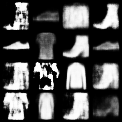

In [ ]:
def tensor_to_pil(image_tensor):
    array = image_tensor.detach().cpu().clamp(0, 1).mul(255).byte().numpy()
    if array.ndim == 3 and array.shape[0] == 1:
        return Image.fromarray(array[0], mode="L")
    if array.ndim == 3 and array.shape[0] == 3:
        return Image.fromarray(np.transpose(array, (1, 2, 0)), mode="RGB")
    raise ValueError(f"Unsupported image tensor shape: {tuple(image_tensor.shape)}")


with torch.inference_mode():
    z = torch.randn(16, LATENT_DIM, device=DEVICE)
    samples = model.decode(z, apply_sigmoid=True)

grid = make_grid(samples.cpu(), nrow=4, padding=2)
image = tensor_to_pil(grid)
image.save(OUTPUT_DIR / "minimal_samples.png")
image


## Part 2: GAN

In [ ]:
GAN_LATENT_DIM = 100
GAN_EPOCHS = 10
GAN_LEARNING_RATE = 2e-4
GAN_BETA1 = 0.5
GAN_OUTPUT_DIR = Path("generated") / "task_2_gan"
GAN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def preprocess_gan_image(image):
    image = image.convert("L")
    x = np.asarray(image, dtype=np.float32) / 127.5 - 1.0
    return torch.from_numpy(x).unsqueeze(0)


class FashionMNISTGanDataset(Dataset):
    def __init__(self, hf_dataset):
        self.hf_dataset = hf_dataset

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, index):
        sample = self.hf_dataset[index]
        return preprocess_gan_image(sample["image"])


gan_train_dataset = FashionMNISTGanDataset(dataset["train"])
gan_train_loader = DataLoader(gan_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

next(iter(gan_train_loader)).shape


torch.Size([128, 1, 28, 28])

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)


generator = Generator(GAN_LATENT_DIM).to(DEVICE)
discriminator = Discriminator().to(DEVICE)


def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
        nn.init.normal_(module.weight.data, 0.0, 0.02)


generator.apply(init_weights)
discriminator.apply(init_weights)

generator, discriminator


(Generator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 Discriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
     (5)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
g_optimizer = torch.optim.Adam(generator.parameters(), lr=GAN_LEARNING_RATE, betas=(GAN_BETA1, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=GAN_LEARNING_RATE, betas=(GAN_BETA1, 0.999))
fixed_noise = torch.randn(16, GAN_LATENT_DIM, 1, 1, device=DEVICE)

for epoch in range(1, GAN_EPOCHS + 1):
    g_losses = []
    d_losses = []

    for real_images in gan_train_loader:
        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)

        real_targets = torch.ones(batch_size, device=DEVICE)
        fake_targets = torch.zeros(batch_size, device=DEVICE)

        d_optimizer.zero_grad()
        real_logits = discriminator(real_images)
        d_real_loss = criterion(real_logits, real_targets)

        noise = torch.randn(batch_size, GAN_LATENT_DIM, 1, 1, device=DEVICE)
        fake_images = generator(noise)
        fake_logits = discriminator(fake_images.detach())
        d_fake_loss = criterion(fake_logits, fake_targets)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        g_optimizer.zero_grad()
        fake_logits = discriminator(fake_images)
        g_loss = criterion(fake_logits, real_targets)
        g_loss.backward()
        g_optimizer.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

    print(
        f"GAN Epoch {epoch:02d} | "
        f"Discriminator loss: {np.mean(d_losses):.4f} | "
        f"Generator loss: {np.mean(g_losses):.4f}"
    )


GAN Epoch 01 | Discriminator loss: 0.6933 | Generator loss: 1.3468
GAN Epoch 02 | Discriminator loss: 0.7139 | Generator loss: 1.5132
GAN Epoch 03 | Discriminator loss: 0.9080 | Generator loss: 1.2498
GAN Epoch 04 | Discriminator loss: 0.9848 | Generator loss: 1.1664
GAN Epoch 05 | Discriminator loss: 1.0282 | Generator loss: 1.1215
GAN Epoch 06 | Discriminator loss: 1.0812 | Generator loss: 1.0757
GAN Epoch 07 | Discriminator loss: 1.1002 | Generator loss: 1.0434
GAN Epoch 08 | Discriminator loss: 1.1273 | Generator loss: 1.0335
GAN Epoch 09 | Discriminator loss: 1.1523 | Generator loss: 1.0144
GAN Epoch 10 | Discriminator loss: 1.1790 | Generator loss: 0.9988


/tmp/ipykernel_5027/2118345706.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(np.transpose(array, (1, 2, 0)), mode="RGB")


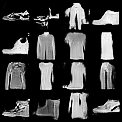

In [ ]:
with torch.inference_mode():
    gan_samples = generator(fixed_noise).cpu()
    gan_samples = (gan_samples + 1.0) / 2.0

gan_grid = make_grid(gan_samples, nrow=4, padding=2)
gan_image = tensor_to_pil(gan_grid)
gan_image.save(GAN_OUTPUT_DIR / "gan_samples.png")
gan_image
